## Predicting Uber Ride Cancellations using Exploratory Data Analysis and Machine Learning

Source Dataset: https://www.kaggle.com/datasets/yashdevladdha/uber-ride-analytics-dashboard/data    
Data Provided By: ?    
Dataset Owner: ?

**Domain:** Urban Mobility & Ride-Hailing Analytics

**Objective:** Build a predictive model to determine whether a customer will cancel a ride before it begins, using only the booking metadata available at the time of booking.
The goal is to help the platform proactively identify high-risk cancellations and optimize driver dispatch efficiency.

### Initiation

##### Import libraries

In [290]:
# Basic imports for data analysis
import pandas as pd
import numpy as np

# Set pandas display options for full visibility
pd.set_option('display.max_columns', None)

# Importing libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Importing libraries for data modeling
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from xgboost import plot_importance

##### Review Data

In [291]:
# Load dataset
df = pd.read_csv('/Users/shubh/Downloads/Capstone/Git/data/ncr_ride_bookings.csv')

df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [292]:
# Variable overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [293]:
# Summary statistics
df.describe(include='all')

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
count,150000,150000,150000,150000,150000,150000,150000,150000,139500.000000,102000.000000,10500.0,10500,27000.0,27000,9000.0,9000,102000.000000,102000.000000,93000.000000,93000.000000,102000
unique,365,62910,148767,5,148788,7,176,176,NaN,NaN,NaN,5,NaN,4,NaN,3,NaN,NaN,NaN,NaN,5
top,2024-11-16,17:44:57,"""CNR7908610""",Completed,"""CID4523979""",Auto,Khandsa,Ashram,NaN,NaN,NaN,Wrong Address,NaN,Customer related issue,NaN,Customer Demand,NaN,NaN,NaN,NaN,UPI
freq,462,16,3,93000,3,37419,949,936,NaN,NaN,NaN,2362,NaN,6837,NaN,3040,NaN,NaN,NaN,NaN,45909
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456352,29.149636,1.0,NaN,1.0,NaN,1.0,NaN,508.295912,24.637012,4.230992,4.404584,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.773564,8.902577,0.0,NaN,0.0,NaN,0.0,NaN,395.805774,14.002138,0.436871,0.437819,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,10.000000,1.0,NaN,1.0,NaN,1.0,NaN,50.000000,1.000000,3.000000,3.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300000,21.600000,1.0,NaN,1.0,NaN,1.0,NaN,234.000000,12.460000,4.100000,4.200000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,28.800000,1.0,NaN,1.0,NaN,1.0,NaN,414.000000,23.720000,4.300000,4.500000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.300000,36.800000,1.0,NaN,1.0,NaN,1.0,NaN,689.000000,36.820000,4.600000,4.800000,NaN


avg_vtat:	Average time for driver to reach pickup location (in minutes)

avg_ctat:	Average trip duration from pickup to destination (in minutes)

### Data Pre-processing

In [294]:
# Clean and standardize column names: 
# - Replace spaces with underscores for easier referencing in code
# - Convert all letters to lowercase for consistency
df.columns = df.columns.str.replace(' ', '_').str.lower()
df.head()

,date,time,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [295]:
# Combine 'Date' and 'Time' into a single datetime column
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Drop original columns if not needed
df.drop(['date', 'time'], axis=1, inplace=True)

In [296]:
# Verify the change
print(df.info())
print(df[['datetime']].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   booking_id                         150000 non-null  object        
 1   booking_status                     150000 non-null  object        
 2   customer_id                        150000 non-null  object        
 3   vehicle_type                       150000 non-null  object        
 4   pickup_location                    150000 non-null  object        
 5   drop_location                      150000 non-null  object        
 6   avg_vtat                           139500 non-null  float64       
 7   avg_ctat                           102000 non-null  float64       
 8   cancelled_rides_by_customer        10500 non-null   float64       
 9   reason_for_cancelling_by_customer  10500 non-null   object        
 10  cancelled_rides_by_d

In [297]:
# Extract datetime features
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['weekday'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])

df.head()

,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend
0,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True
1,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False
2,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False
3,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False
4,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False


In [298]:
# Remove double quotes from column values of 'booking_id' and 'customer_id'
df['booking_id'] = df['booking_id'].str.strip('"')
df['customer_id'] = df['customer_id'].str.strip('"')
df.head()

,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend
0,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True
1,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False
2,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False
3,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False
4,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False


In [299]:
# check for duplicate rows 
df.duplicated().sum()

np.int64(0)

In [300]:
# Check unique values in categorical columns
print("Vehicle Types:", df['vehicle_type'].unique())
print("Booking statuses:", df['booking_status'].unique())

Vehicle Types: ['eBike' 'Go Sedan' 'Auto' 'Premier Sedan' 'Bike' 'Go Mini' 'Uber XL']
Booking statuses: ['No Driver Found' 'Incomplete' 'Completed' 'Cancelled by Driver'
 'Cancelled by Customer']


In [301]:
# Check for Nulls
df.isna().sum()

booking_id                                0
booking_status                            0
customer_id                               0
vehicle_type                              0
pickup_location                           0
drop_location                             0
avg_vtat                              10500
avg_ctat                              48000
cancelled_rides_by_customer          139500
reason_for_cancelling_by_customer    139500
cancelled_rides_by_driver            123000
driver_cancellation_reason           123000
incomplete_rides                     141000
incomplete_rides_reason              141000
booking_value                         48000
ride_distance                         48000
driver_ratings                        57000
customer_rating                       57000
payment_method                        48000
datetime                                  0
hour                                      0
day_of_week                               0
weekday                         

In [302]:
# Check for missing values in 'avg_vtat' 
df[df['avg_vtat'].isnull()].head()

,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend
0,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True
8,CNR4510807,No Driver Found,CID7873618,Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-14 12:49:09,12,Saturday,5,9,True
11,CNR9551927,No Driver Found,CID7568143,Auto,Vidhan Sabha,AIIMS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-09-18 08:09:38,8,Wednesday,2,9,False
27,CNR4499383,No Driver Found,CID5717521,Premier Sedan,Sadar Bazar Gurgaon,Mehrauli,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-12 19:42:35,19,Friday,4,4,False
57,CNR9773309,No Driver Found,CID9965847,Uber XL,Anand Vihar ISBT,Dwarka Sector 21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-11 15:43:34,15,Thursday,3,4,False


In [303]:
# Check which booking statuses have missing 'avg_vtat'
df[df['avg_vtat'].isnull()]['booking_status'].unique()

array(['No Driver Found'], dtype=object)

In [304]:
# Check booking statuses for cancelled rides by customer
df[df['cancelled_rides_by_customer']==1]['booking_status'].unique()

array(['Cancelled by Customer'], dtype=object)

In [305]:
# cancelled_rides_by_customer vs booking_status 
pd.crosstab(df['booking_status'], df['cancelled_rides_by_customer'], dropna=False)

cancelled_rides_by_customer,1.0,NaN
booking_status,,
Cancelled by Customer,10500,0
Cancelled by Driver,0,27000
Completed,0,93000
Incomplete,0,9000
No Driver Found,0,10500


In [306]:
# cancelled_rides_by_driver vs booking_status 
pd.crosstab(df['booking_status'], df['cancelled_rides_by_driver'], dropna=False)

cancelled_rides_by_driver,1.0,NaN
booking_status,,
Cancelled by Customer,0,10500
Cancelled by Driver,27000,0
Completed,0,93000
Incomplete,0,9000
No Driver Found,0,10500


In [307]:
# filling NaN as O "not cancelled"
df['cancelled_rides_by_customer'] = df['cancelled_rides_by_customer'].fillna(0).astype(int)
df['cancelled_rides_by_driver'] = df['cancelled_rides_by_driver'].fillna(0).astype(int)
df['incomplete_rides'] = df['incomplete_rides'].fillna(0).astype(int)

In [308]:
df.head()

,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend
0,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True
1,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False
2,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False
3,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False
4,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False


In [309]:
# Create binary flags from cancellation/incomplete columns
#df['is_cancelled_customer'] = df['cancelled_rides_by_customer'].notnull()
#df['is_cancelled_driver'] = df['cancelled_rides_by_driver'].notnull()
#df['is_incomplete'] = df['incomplete_rides'].notnull()

# Create a flag for missing ratings and booking values
df['missing_driver_rating'] = df['driver_ratings'].isnull().astype(int)
df['missing_customer_rating'] = df['customer_rating'].isnull().astype(int)
df['missing_booking_value'] = df['booking_value'].isnull().astype(int)
df['missing_payment_method'] = df['payment_method'].isnull().astype(int)

In [310]:
# Check number of unique bookings
df['booking_id'].nunique()

148767

In [311]:
# Check total number of records
len(df)

150000

In [312]:
df.head()

,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method
0,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True,1,1,1,1
1,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False,1,1,0,0
2,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False,0,0,0,0
3,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False,0,0,0,0
4,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False,0,0,0,0


In [313]:
# Check for missing Booking IDs and Customer IDs 

print(df['booking_id'].isnull().sum())
print(df['customer_id'].isnull().sum())

0
0


In [314]:
# Check for duplicate Booking IDs
dup_mask = df['booking_id'].duplicated(keep='first')
print("duplicate rows (excluding first):", dup_mask.sum())
df[dup_mask].head()

duplicate rows (excluding first): 1233


,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method
5522,CNR5071968,No Driver Found,CID6309096,Auto,Kanhaiya Nagar,India Gate,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-10 19:55:06,19,Sunday,6,3,True,1,1,1,1
7762,CNR8512595,Completed,CID9741888,Go Mini,Narsinghpur,Huda City Centre,3.5,15.4,0,NaN,0,NaN,0,NaN,187.0,41.45,4.4,4.2,Credit Card,2024-03-01 11:55:56,11,Friday,4,3,False,0,0,0,0
9587,CNR1029172,Completed,CID6382731,Auto,Inderlok,Laxmi Nagar,6.9,34.4,0,NaN,0,NaN,0,NaN,332.0,36.38,4.3,4.3,UPI,2024-12-17 19:19:02,19,Tuesday,1,12,False,0,0,0,0
9726,CNR7132372,Completed,CID6950827,Go Sedan,Kalkaji,Sushant Lok,3.8,18.3,0,NaN,0,NaN,0,NaN,389.0,44.95,3.7,4.2,UPI,2024-05-23 20:44:27,20,Thursday,3,5,False,0,0,0,0
10186,CNR7768664,Completed,CID4473762,eBike,Anand Vihar ISBT,Netaji Subhash Place,5.1,42.1,0,NaN,0,NaN,0,NaN,357.0,17.03,4.2,4.2,UPI,2024-12-14 21:15:59,21,Saturday,5,12,True,0,0,0,0


In [315]:
# Inspecting a duplicate booking_id to check their booking statuses
df[df['booking_id']=='CNR5071968']

,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method
317,CNR5071968,Completed,CID7384045,Go Sedan,Panchsheel Park,Yamuna Bank,4.7,42.5,0,NaN,0,NaN,0,NaN,473.0,48.35,4.7,3.8,Cash,2024-10-10 03:56:19,3,Thursday,3,10,False,0,0,0,0
5522,CNR5071968,No Driver Found,CID6309096,Auto,Kanhaiya Nagar,India Gate,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-10 19:55:06,19,Sunday,6,3,True,1,1,1,1


In [316]:
df[df['booking_id']=='CNR8512595']

,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method
1893,CNR8512595,Completed,CID8017027,Auto,Ashok Vihar,Mehrauli,14.6,29.6,0,NaN,0,NaN,0,NaN,294.0,44.22,3.6,5.0,Cash,2024-11-02 10:45:25,10,Saturday,5,11,True,0,0,0,0
7762,CNR8512595,Completed,CID9741888,Go Mini,Narsinghpur,Huda City Centre,3.5,15.4,0,NaN,0,NaN,0,NaN,187.0,41.45,4.4,4.2,Credit Card,2024-03-01 11:55:56,11,Friday,4,3,False,0,0,0,0


In [317]:
# create missing flags and impute avg_vtat / avg_ctat by median per vehicle_type (fallback to global median)
df['avg_vtat_missing'] = df['avg_vtat'].isnull().astype(int)
df['avg_ctat_missing'] = df['avg_ctat'].isnull().astype(int)

# median per vehicle type, then fallback to overall median if vehicle-type median is NaN
vtat_med_by_type = df.groupby(['vehicle_type','pickup_location'])['avg_vtat'].transform('median')
ctat_med_by_type = df.groupby(['vehicle_type','pickup_location'])['avg_ctat'].transform('median')

df['avg_vtat_imputed'] = df['avg_vtat'].fillna(vtat_med_by_type).fillna(df['avg_vtat'].median())
df['avg_ctat_imputed'] = df['avg_ctat'].fillna(ctat_med_by_type).fillna(df['avg_ctat'].median())

# Optional: drop or keep original columns. Defaults keep both original and imputed.
# df.drop(['avg_vtat','avg_ctat'], axis=1, inplace=True)  # uncomment if you want to replace originals

In [318]:
df.head()

,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,avg_vtat_missing,avg_ctat_missing,avg_vtat_imputed,avg_ctat_imputed
0,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True,1,1,1,1,1,1,9.7,28.15
1,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False,1,1,0,0,0,0,4.9,14.00
2,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False,0,0,0,0,0,0,13.4,25.80
3,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False,0,0,0,0,0,0,13.1,28.50
4,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False,0,0,0,0,0,0,5.3,19.60


In [319]:
# df1= df.drop('booking_id', axis=1)
# df1.head()

# Exploratory Data Analysis (EDA)

##### •	Cancellation patterns: By hour, weekday/weekend, vehicle type, and location.

##### •	Customer behavior: Analyze repeat cancellations per customer.

##### •	Operational metrics: Impact of higher avg_vtat (driver arrival time), avg_ctat(ride time) on cancellations.

Notes:

- For cancelled rides, the variables 'ride distance', 'booking value', 'customer rating', and 'driver rating' contain null values, as these metrics are only recorded for successfully completed rides. Consequently, Exploratory Data Analysis (EDA) on these variables is not feasible for cancelled rides.

- Although a deeper analysis of cancellation patterns could be conducted by:
	
	1.	Estimating ride distance — e.g., calculating the geodesic distance between pickup and drop-off coordinates, and

	2.	Assessing rating correlations — e.g., comparing average customer or driver ratings across a larger dataset,
	such analyses fall outside the scope of the current project due to dataset constraints and limited sample size.

#### Cancellation Patterns

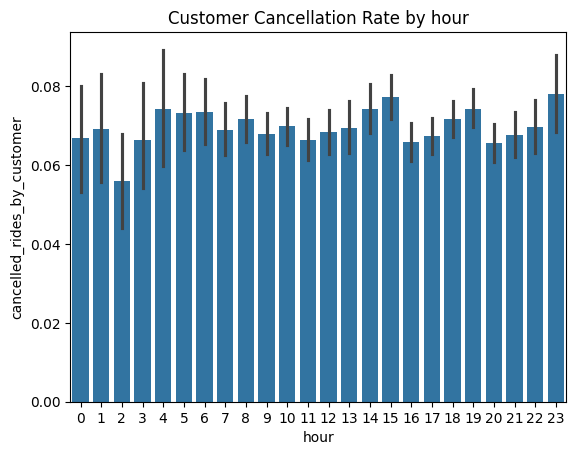

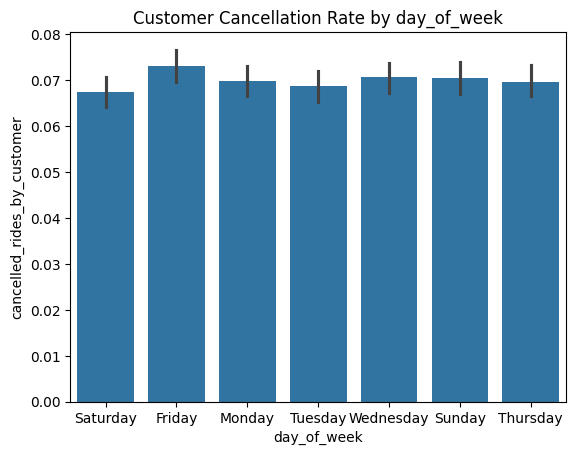

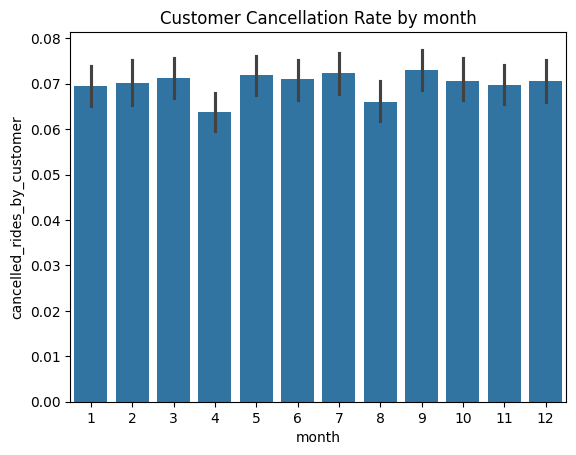

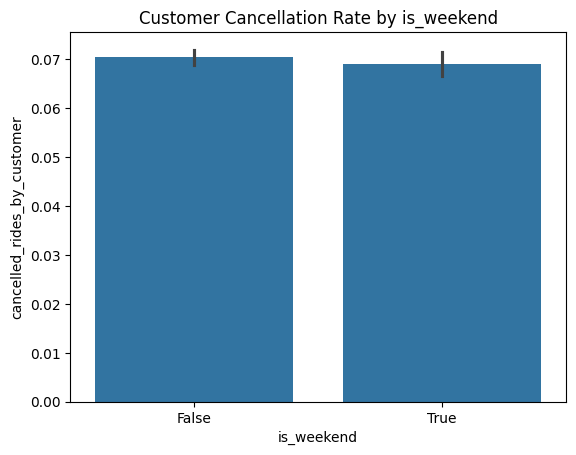

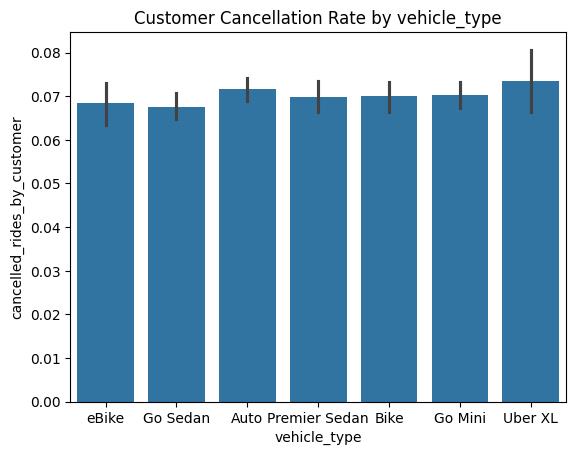

In [320]:
# Cancellation Patterns Visualization by 'hour', 'day_of_week', 'month', 'is_weekend', 'vehicle_type'

for i in ['hour', 'day_of_week', 'month', 'is_weekend', 'vehicle_type']:
     sns.barplot(x=df[i], y= df['cancelled_rides_by_customer'])
     plt.title(f"Customer Cancellation Rate by {i}")
     plt.show()

1. Customer Cancellation rate (%) is highest at 23:00 and 15:00 hours per day, on Fridays
2. Customer Cancellation rate (%) is lowest in April and August.


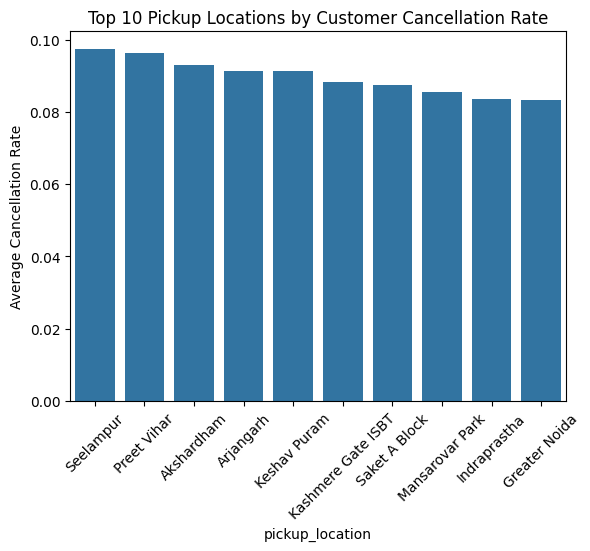

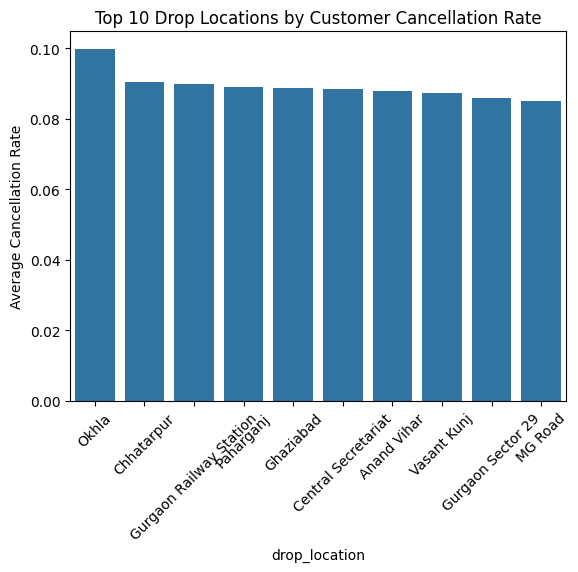

In [321]:
df_pickup = df.groupby('pickup_location')['cancelled_rides_by_customer'].mean().sort_values(ascending=False).head(10).reset_index()
df_drop = df.groupby('drop_location')['cancelled_rides_by_customer'].mean().sort_values(ascending=False).head(10).reset_index()

sns.barplot(x='pickup_location', y='cancelled_rides_by_customer', data=df_pickup)
plt.title("Top 10 Pickup Locations by Customer Cancellation Rate")
plt.xlabel("pickup_location")
plt.ylabel("Average Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

sns.barplot(x='drop_location', y='cancelled_rides_by_customer', data=df_drop)
plt.title("Top 10 Drop Locations by Customer Cancellation Rate")
plt.xlabel("drop_location")
plt.ylabel("Average Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

# plt.xlabel("Hour of Day")
# plt.ylabel("Average Cancellation Rate")
# plt.show()

1. Customer Cancellation rate (%) is highest from pickup location 'Seelampur' and with drop location 'Okhla'

In [322]:
df.head()

,booking_id,booking_status,customer_id,vehicle_type,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,day_of_week,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,avg_vtat_missing,avg_ctat_missing,avg_vtat_imputed,avg_ctat_imputed
0,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday,5,3,True,1,1,1,1,1,1,9.7,28.15
1,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday,4,11,False,1,1,0,0,0,0,4.9,14.00
2,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday,4,8,False,0,0,0,0,0,0,13.4,25.80
3,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday,0,10,False,0,0,0,0,0,0,13.1,28.50
4,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday,0,9,False,0,0,0,0,0,0,5.3,19.60


In [323]:
# for i in ['ride_distance', 'booking_value', 'driver_ratings', 'customer_rating']:
#      sns.barplot(x=df[i], y= df['cancelled_rides_by_customer'])
#      plt.title(f"Customer Cancellation Rate by {i}")
#      plt.show()

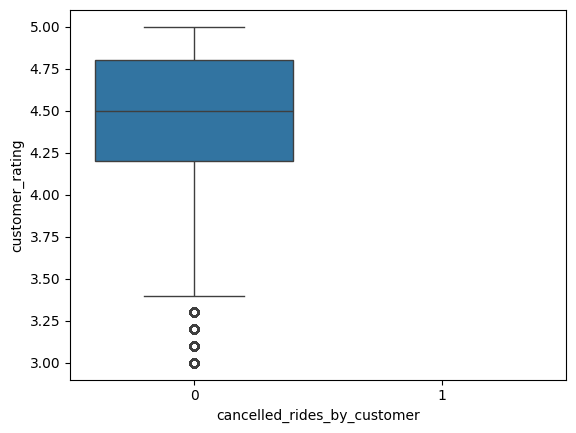

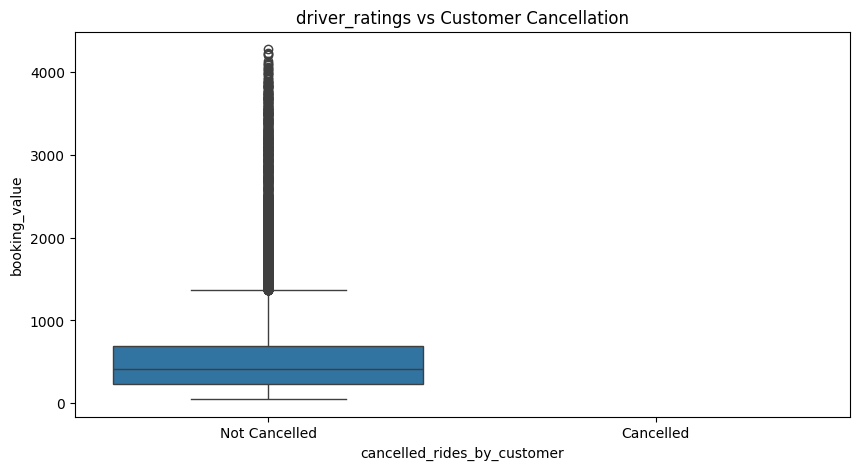

In [324]:
# sns.barplot(x=df['ride_distance'], y=df['cancelled_rides_by_customer'])
# plt.title("Customer Cancellation Rate by ride_distance")
# plt.xlabel("ride_distance")
# plt.ylabel("Average Cancellation Rate")
# plt.show()

# sns.barplot(x='booking_value', y='cancelled_rides_by_customer', data=df)
# plt.title("Customer Cancellation Rate by booking_value")
# plt.xlabel("booking_value")
# plt.ylabel("Average Cancellation Rate")
# plt.show()

#sns.boxplot(x='driver_ratings', y='cancelled_rides_by_customer', data=df)
# plt.title("Customer Cancellation Rate by driver_ratings")
# plt.xlabel("driver_ratings")
# plt.ylabel("Average Cancellation Rate")
# plt.show()


sns.boxplot(y='customer_rating', x='cancelled_rides_by_customer', data=df)
# plt.title("Customer Cancellation Rate by customer_rating")
# plt.xlabel("customer_rating")
# plt.ylabel("Average Cancellation Rate")
# plt.show()


plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='cancelled_rides_by_customer', y='booking_value')
plt.title("driver_ratings vs Customer Cancellation")
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.show()

In [325]:
df[df['cancelled_rides_by_customer']==1].groupby('customer_id').size().sort_values(ascending=False).head(10).reset_index()  

,customer_id,0
0,CID8416905,2
1,CID7939117,2
2,CID5251785,2
3,CID5505307,2
4,CID2358909,2
5,CID5488244,2
6,CID8887672,2
7,CID8519067,2
8,CID7079917,1
9,CID7042696,1


We don't have many repeated customer cancellations. Only 7 customers have cancelled twice. So, there is no pattern of cancelled rides with customer IDs.

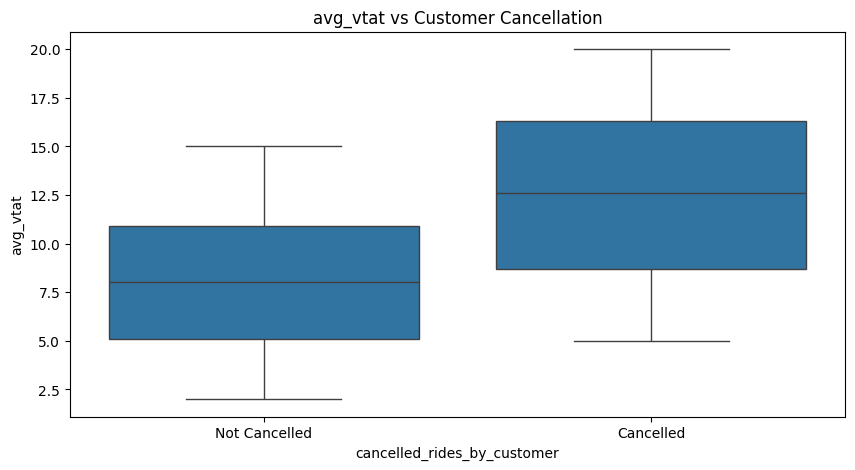

In [326]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='cancelled_rides_by_customer', y='avg_vtat')
plt.title("avg_vtat vs Customer Cancellation")
plt.xticks([0, 1], ['Not Cancelled', 'Cancelled'])
plt.show()

We can clearly see here that avg_vtat (driver arrival time) is higher for cancelled rides with a median around 12.5 minutes and for not cancelled rides is around 7.5 minutes. So, avg_vtat is our key driver that coorelate with customer cancellations.

## Feature Engineering

Enhance predictive power with derived features such as:

- Customer-related: Customer_Cancel_Rate → (Past cancelled rides / total rides per customer)

- Time-based:	Is_Peak_Hour

- Location-based: Encode frequent cancellation zones using clustering or frequency encoding.

- Value-related: Categorize rides by price range or distance bucket.


📈 Output: Feature-enriched dataset that captures behavioral, spatial, and temporal signals.

In [327]:
# Define peak hours: 7-10 AM and 5-8 PM
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 10) or (17 <= x <= 20) else 0)
df[['hour','is_peak_hour']].head(10)

,hour,is_peak_hour
0,12,0
1,18,1
2,8,1
3,17,1
4,22,0
5,9,1
6,15,0
7,17,1
8,12,0
9,19,1


In [328]:
df1 = df.copy()
df1 = pd.get_dummies(df, columns=['vehicle_type', 'day_of_week'], drop_first=True)
df1.head()

# dummies
# booking_status, payment_method

,booking_id,booking_status,customer_id,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,payment_method,datetime,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,avg_vtat_missing,avg_ctat_missing,avg_vtat_imputed,avg_ctat_imputed,is_peak_hour,vehicle_type_Bike,vehicle_type_Go Mini,vehicle_type_Go Sedan,vehicle_type_Premier Sedan,vehicle_type_Uber XL,vehicle_type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,CNR5884300,No Driver Found,CID1982111,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False
1,CNR1326809,Incomplete,CID4604802,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False
2,CNR8494506,Completed,CID9202816,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False
3,CNR8906825,Completed,CID2610914,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False
4,CNR1950162,Completed,CID9933542,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,0,9,False,0,0,0,0,0,0,5.3,19.60,0,True,False,False,False,False,False,True,False,False,False,False,False


In [329]:
df1['payment_method'] = df1['payment_method'].fillna('Unknown')
df1 = pd.get_dummies(df1, columns=['payment_method'], drop_first=True)
df1.head()

,booking_id,booking_status,customer_id,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,datetime,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,avg_vtat_missing,avg_ctat_missing,avg_vtat_imputed,avg_ctat_imputed,is_peak_hour,vehicle_type_Bike,vehicle_type_Go Mini,vehicle_type_Go Sedan,vehicle_type_Premier Sedan,vehicle_type_Uber XL,vehicle_type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,payment_method_Uber Wallet,payment_method_Unknown
0,CNR5884300,No Driver Found,CID1982111,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True
1,CNR1326809,Incomplete,CID4604802,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,2024-11-29 18:01:39,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,CNR8494506,Completed,CID9202816,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,2024-08-23 08:56:10,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,CNR8906825,Completed,CID2610914,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,2024-10-21 17:17:25,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False
4,CNR1950162,Completed,CID9933542,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,2024-09-16 22:08:00,22,0,9,False,0,0,0,0,0,0,5.3,19.60,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False



drop


booking_id, reason_for_cancelling_by_customer, driver_cancellation_reason, cancelled_rides_by_driver, incomplete_rides, incomplete_rides_reason, datetime, avg Vtat, avg CTAt

In [330]:
# Encoding Top 10 Pickup Locations by occurrence & customer cancellation
top_pickups = df1['pickup_location'].value_counts().nlargest(10).index
top_pickups_cus_canc = df1[df1['cancelled_rides_by_customer'] == 1]['pickup_location'].value_counts().nlargest(10).index
df1['pickup_encoded'] = df1['pickup_location'].apply(lambda x: x if x in top_pickups else 'Other')
df1['pickup_encoded_cus_canc'] = df1['pickup_location'].apply(lambda x: x if x in top_pickups_cus_canc else 'Other')
df1 = pd.get_dummies(df1, columns=['pickup_encoded'], prefix='pickup', drop_first=True)
df1 = pd.get_dummies(df1, columns=['pickup_encoded_cus_canc'], prefix='pickup_cus_canc', drop_first=True)

# Encoding Top 10 Drop Locations by occurrence & customer cancellation
top_drops = df1['drop_location'].value_counts().nlargest(10).index
top_drops_cus_canc = df1[df1['cancelled_rides_by_customer'] == 1]['drop_location'].value_counts().nlargest(10).index
df1['drop_encoded'] = df1['drop_location'].apply(lambda x: x if x in top_drops else 'Other')
df1['drop_encoded_cus_canc'] = df1['drop_location'].apply(lambda x: x if x in top_drops_cus_canc else 'Other')
df1 = pd.get_dummies(df1, columns=['drop_encoded'], prefix='drop', drop_first=True)
df1 = pd.get_dummies(df1, columns=['drop_encoded_cus_canc'], prefix='drop_cus_canc', drop_first=True)
df1.head()

,booking_id,booking_status,customer_id,pickup_location,drop_location,avg_vtat,avg_ctat,cancelled_rides_by_customer,reason_for_cancelling_by_customer,cancelled_rides_by_driver,driver_cancellation_reason,incomplete_rides,incomplete_rides_reason,booking_value,ride_distance,driver_ratings,customer_rating,datetime,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,avg_vtat_missing,avg_ctat_missing,avg_vtat_imputed,avg_ctat_imputed,is_peak_hour,vehicle_type_Bike,vehicle_type_Go Mini,vehicle_type_Go Sedan,vehicle_type_Premier Sedan,vehicle_type_Uber XL,vehicle_type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,payment_method_Uber Wallet,payment_method_Unknown,pickup_Badarpur,pickup_Barakhamba Road,pickup_Dwarka Sector 21,pickup_Khandsa,pickup_Madipur,pickup_Mehrauli,pickup_Other,pickup_Pataudi Chowk,pickup_Pragati Maidan,pickup_Saket,pickup_cus_canc_Arjangarh,pickup_cus_canc_Badarpur,pickup_cus_canc_Greater Kailash,pickup_cus_canc_Greater Noida,pickup_cus_canc_Kashmere Gate ISBT,pickup_cus_canc_Keshav Puram,pickup_cus_canc_Mansarovar Park,pickup_cus_canc_Other,pickup_cus_canc_Preet Vihar,pickup_cus_canc_Seelampur,drop_Basai Dhankot,drop_Cyber Hub,drop_Kalkaji,drop_Kashmere Gate ISBT,drop_Lajpat Nagar,drop_Lok Kalyan Marg,drop_Narsinghpur,drop_Nehru Place,drop_Other,drop_Udyog Vihar,drop_cus_canc_Bahadurgarh,drop_cus_canc_Central Secretariat,drop_cus_canc_Chhatarpur,drop_cus_canc_Ghaziabad,drop_cus_canc_Gurgaon Railway Station,drop_cus_canc_Kalkaji,drop_cus_canc_Okhla,drop_cus_canc_Other,drop_cus_canc_Paharganj,drop_cus_canc_Uttam Nagar
0,CNR5884300,No Driver Found,CID1982111,Palam Vihar,Jhilmil,NaN,NaN,0,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
1,CNR1326809,Incomplete,CID4604802,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,0,NaN,0,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,2024-11-29 18:01:39,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,CNR8494506,Completed,CID9202816,Khandsa,Malviya Nagar,13.4,25.8,0,NaN,0,NaN,0,NaN,627.0,13.58,4.9,4.9,2024-08-23 08:56:10,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,CNR8906825,Completed,CID2610914,Central Secretariat,Inderlok,13.1,28.5,0,NaN,0,NaN,0,NaN,416.0,34.02,4.6,5.0,2024-10-21 17:17:25,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,CNR1950162,Completed,CID9933542,Ghitorni Village,Khan Market,5.3,19.6,0,NaN,0,NaN,0,NaN,737.0,48.21,4.1,4.3,2024-09-16 22:08:00,22,0,9,False,0,0,0,0,0,0,5.3,19.60,0,True,False,False,False,False,False,Tr

In [331]:
df1 = df1.drop(['booking_id', 'booking_status', 'pickup_location', 'drop_location', 'reason_for_cancelling_by_customer', 'driver_cancellation_reason', 
                'cancelled_rides_by_driver', 'incomplete_rides', 'incomplete_rides_reason',
                'datetime', 'avg_vtat', 'avg_ctat'], axis=1)
df1.head()

,customer_id,cancelled_rides_by_customer,booking_value,ride_distance,driver_ratings,customer_rating,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,avg_vtat_missing,avg_ctat_missing,avg_vtat_imputed,avg_ctat_imputed,is_peak_hour,vehicle_type_Bike,vehicle_type_Go Mini,vehicle_type_Go Sedan,vehicle_type_Premier Sedan,vehicle_type_Uber XL,vehicle_type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,payment_method_Uber Wallet,payment_method_Unknown,pickup_Badarpur,pickup_Barakhamba Road,pickup_Dwarka Sector 21,pickup_Khandsa,pickup_Madipur,pickup_Mehrauli,pickup_Other,pickup_Pataudi Chowk,pickup_Pragati Maidan,pickup_Saket,pickup_cus_canc_Arjangarh,pickup_cus_canc_Badarpur,pickup_cus_canc_Greater Kailash,pickup_cus_canc_Greater Noida,pickup_cus_canc_Kashmere Gate ISBT,pickup_cus_canc_Keshav Puram,pickup_cus_canc_Mansarovar Park,pickup_cus_canc_Other,pickup_cus_canc_Preet Vihar,pickup_cus_canc_Seelampur,drop_Basai Dhankot,drop_Cyber Hub,drop_Kalkaji,drop_Kashmere Gate ISBT,drop_Lajpat Nagar,drop_Lok Kalyan Marg,drop_Narsinghpur,drop_Nehru Place,drop_Other,drop_Udyog Vihar,drop_cus_canc_Bahadurgarh,drop_cus_canc_Central Secretariat,drop_cus_canc_Chhatarpur,drop_cus_canc_Ghaziabad,drop_cus_canc_Gurgaon Railway Station,drop_cus_canc_Kalkaji,drop_cus_canc_Okhla,drop_cus_canc_Other,drop_cus_canc_Paharganj,drop_cus_canc_Uttam Nagar
0,CID1982111,0,NaN,NaN,NaN,NaN,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
1,CID4604802,0,237.0,5.73,NaN,NaN,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,CID9202816,0,627.0,13.58,4.9,4.9,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,CID2610914,0,416.0,34.02,4.6,5.0,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,CID9933542,0,737.0,48.21,4.1,4.3,22,0,9,False,0,0,0,0,0,0,5.3,19.60,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False


In [332]:
booking_value_median = df1['booking_value'].median()
ride_distance_median = df1['ride_distance'].median()
driver_rating_median = df1['driver_ratings'].median()
customer_rating_median = df1['customer_rating'].median()
df1['booking_value'] = df1['booking_value'].fillna(booking_value_median)
df1['ride_distance'] = df1['ride_distance'].fillna(ride_distance_median)
df1['driver_ratings'] = df1['driver_ratings'].fillna(driver_rating_median)
df1['customer_rating'] = df1['customer_rating'].fillna(customer_rating_median)
df1.head()

,customer_id,cancelled_rides_by_customer,booking_value,ride_distance,driver_ratings,customer_rating,hour,weekday,month,is_weekend,missing_driver_rating,missing_customer_rating,missing_booking_value,missing_payment_method,avg_vtat_missing,avg_ctat_missing,avg_vtat_imputed,avg_ctat_imputed,is_peak_hour,vehicle_type_Bike,vehicle_type_Go Mini,vehicle_type_Go Sedan,vehicle_type_Premier Sedan,vehicle_type_Uber XL,vehicle_type_eBike,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,payment_method_Uber Wallet,payment_method_Unknown,pickup_Badarpur,pickup_Barakhamba Road,pickup_Dwarka Sector 21,pickup_Khandsa,pickup_Madipur,pickup_Mehrauli,pickup_Other,pickup_Pataudi Chowk,pickup_Pragati Maidan,pickup_Saket,pickup_cus_canc_Arjangarh,pickup_cus_canc_Badarpur,pickup_cus_canc_Greater Kailash,pickup_cus_canc_Greater Noida,pickup_cus_canc_Kashmere Gate ISBT,pickup_cus_canc_Keshav Puram,pickup_cus_canc_Mansarovar Park,pickup_cus_canc_Other,pickup_cus_canc_Preet Vihar,pickup_cus_canc_Seelampur,drop_Basai Dhankot,drop_Cyber Hub,drop_Kalkaji,drop_Kashmere Gate ISBT,drop_Lajpat Nagar,drop_Lok Kalyan Marg,drop_Narsinghpur,drop_Nehru Place,drop_Other,drop_Udyog Vihar,drop_cus_canc_Bahadurgarh,drop_cus_canc_Central Secretariat,drop_cus_canc_Chhatarpur,drop_cus_canc_Ghaziabad,drop_cus_canc_Gurgaon Railway Station,drop_cus_canc_Kalkaji,drop_cus_canc_Okhla,drop_cus_canc_Other,drop_cus_canc_Paharganj,drop_cus_canc_Uttam Nagar
0,CID1982111,0,414.0,23.72,4.3,4.5,12,5,3,True,1,1,1,1,1,1,9.7,28.15,0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
1,CID4604802,0,237.0,5.73,4.3,4.5,18,4,11,False,1,1,0,0,0,0,4.9,14.00,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
2,CID9202816,0,627.0,13.58,4.9,4.9,8,4,8,False,0,0,0,0,0,0,13.4,25.80,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
3,CID2610914,0,416.0,34.02,4.6,5.0,17,0,10,False,0,0,0,0,0,0,13.1,28.50,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,CID9933542,0,737.0,48.21,4.1,4.3,22,0,9,False,0,0,0,0,0,0,5.3,19.60,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False


## Model Building

Train supervised classification models to predict cancellation probability.

Baseline models:
	•	Logistic Regression
	•	Decision Tree
	•	Random Forest
	•	XGBoost / LightGBM
	•	CatBoost

Model Pipeline:
	1.	Split data into train/test sets (e.g., 80/20).
	2.	Perform cross-validation for robustness.
	3.	Optimize hyperparameters using GridSearch or RandomizedSearch.
	4.	Evaluate with relevant metrics.

In [333]:
X = df1.drop('cancelled_rides_by_customer', axis=1)
y = df1['cancelled_rides_by_customer']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Customer counts in training set
cust_counts = X_train['customer_id'].value_counts().to_dict()
X_train['customer_total_bookings'] = X_train['customer_id'].map(cust_counts)

# # Mapping to test set, fill NaN with 0 for unseen customers 
X_test['customer_total_bookings'] = X_test['customer_id'].map(cust_counts).fillna(0)

# # drop 'customer_id' after deriving features
X_train = X_train.drop('customer_id', axis=1)
X_test = X_test.drop('customer_id', axis=1)

In [334]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression

In [335]:
clf = LogisticRegression().fit(X_train_scaled, y_train)
print(clf.coef_)
print(clf.intercept_)

[[-0.50424047 -1.9159257  -2.53121792 -2.87261279  0.07081459 -1.49603704
   0.02330118  0.19485145  0.96329525  0.96329525  1.71539529  1.71539529
  -5.19164358  1.71539529  7.71491041 -1.66272303 -0.01963685 -0.05258246
  -0.02940724 -0.07444844 -0.03812312  0.02243073 -0.13105906 -1.07020549
  -0.0796508   0.27450225 -0.29075015 -0.84979798 -0.4820626  -0.66235802
  -0.53560719 -2.24563985 -0.77477401  1.71539529 -0.2289535  -0.30344056
  -0.34213917 -0.58136586 -0.43984173 -0.2855093  -0.33167873 -0.20170581
  -0.29484526 -0.37336431 -0.11569832 -0.2289535  -0.53753341 -0.33057183
  -0.46305374 -0.34386225 -0.41432417 -0.53171174 -0.22375383  0.1459099
  -0.16522462  0.05330681 -0.24419572 -0.62160143 -0.39145445 -0.32247577
  -0.43659439 -0.58085911 -0.32735383 -0.60746081 -0.50821541 -0.29158857
  -0.25564081 -0.39484062 -0.16810072 -0.24419572 -0.30730065 -0.52976031
  -0.28650774 -0.42350861  0.16008594]]
[-4.67829153]


In [336]:
y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)[:, 1]

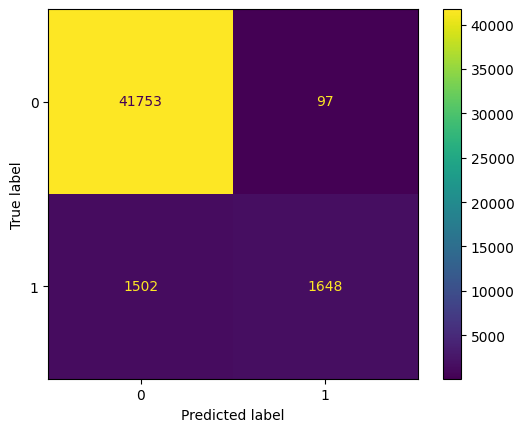

In [337]:
cm = metrics.confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

In [338]:
print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred, digits=3))

ROC AUC Score: 0.9639891904192979

Classification Report:
               precision    recall  f1-score   support

           0      0.965     0.998     0.981     41850
           1      0.944     0.523     0.673      3150

    accuracy                          0.964     45000
   macro avg      0.955     0.760     0.827     45000
weighted avg      0.964     0.964     0.960     45000



# Random Forest

In [339]:
# %%time

# cv_params = {
#     'max_depth': [2],
#     'min_samples_leaf': [1],
#     'min_samples_split': [2],
#     'max_features': [2],
#     'n_estimators': [100]
# }

# rf = RandomForestClassifier(random_state=42)
# scoring = ['accuracy', 'recall']
# split_index = [0 if x in X_test_scaled.index else -1 for x in X_train_scaled.index]
# custom_split = PredefinedSplit(split_index)
# grid_search = GridSearchCV(estimator=rf, param_grid=cv_params, scoring=scoring, refit='recall', cv=custom_split)

In [340]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Predict & Evaluate
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("ROC AUC Score:", metrics.roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred_rf, digits=3))

ROC AUC Score: 0.9639614723786767

Classification Report:
               precision    recall  f1-score   support

           0      0.966     0.999     0.982     41850
           1      0.968     0.530     0.685      3150

    accuracy                          0.966     45000
   macro avg      0.967     0.764     0.833     45000
weighted avg      0.966     0.966     0.961     45000



## XGBoost

In [341]:
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=13.29,
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

# Predict & Evaluate
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("🎯 ROC AUC Score:", metrics.roc_auc_score(y_test, y_prob_xgb))
print("\n📋 Classification Report:\n", metrics.classification_report(y_test, y_pred_xgb, digits=3))

/Users/shubh/Downloads/Capstone/Git/uber-ride-cancellation-prediction/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [19:11:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🎯 ROC AUC Score: 0.9629323358176405

📋 Classification Report:
               precision    recall  f1-score   support

           0      0.993     0.873     0.929     41850
           1      0.351     0.912     0.507      3150

    accuracy                          0.876     45000
   macro avg      0.672     0.893     0.718     45000
weighted avg      0.948     0.876     0.899     45000



<Figure size 1000x600 with 0 Axes>

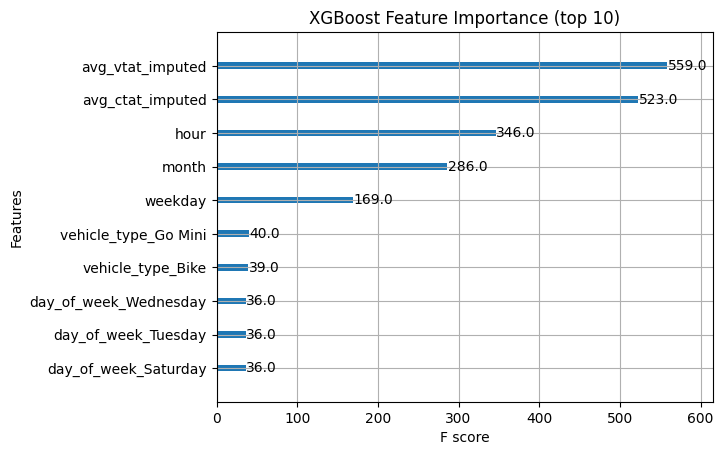

In [342]:
# plot importance from the fitted XGBClassifier (use its booster)
plt.figure(figsize=(10, 6))
plot_importance(xgb.get_booster(), max_num_features=10)
plt.title("XGBoost Feature Importance (top 10)")
plt.show()

Best recall, accuracy out of these models

Why recall, accuracy?



Cancellations are high when VTAT is high
Driver reblancing on pickup locations which has high VTAT as high VTAT is the greatest contributor to customer cancellations.